# Skin Cancer Classification Using Deep Learning

## Objective
The objective of this project is to classify skin lesion images into different categories using deep learning techniques.

## Dataset
The HAM10000 dataset contains dermatoscopic images of skin lesions belonging to seven different classes.

## Approach
A Convolutional Neural Network (CNN) will be used to automatically learn features from images and classify them.

In [40]:
import os
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

## Dataset Metadata Overview

The metadata file contains information about each skin lesion image, including the image ID, lesion type, patient age, sex, and localization.

This step is used to understand the structure of the dataset before image preprocessing and model training.

In [41]:
df = pd.read_csv("HAM10000_metadata.csv")

In [42]:
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  str    
 1   image_id      10015 non-null  str    
 2   dx            10015 non-null  str    
 3   dx_type       10015 non-null  str    
 4   age           9958 non-null   float64
 5   sex           10015 non-null  str    
 6   localization  10015 non-null  str    
dtypes: float64(1), str(6)
memory usage: 547.8 KB


In [44]:
df["dx"].value_counts()

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

## Creating Image Paths

The metadata file contains only image IDs, while the actual image files are stored in two folders.

In this step, a full path is created for each image so that the model can access the image files during training.

In [45]:
import os

image_dir_1 = "HAM10000_images_part_1"
image_dir_2 = "HAM10000_images_part_2"

def get_image_path(image_id):
    path1 = os.path.join(image_dir_1, image_id + ".jpg")
    path2 = os.path.join(image_dir_2, image_id + ".jpg")
    
    if os.path.exists(path1):
        return path1
    elif os.path.exists(path2):
        return path2
    else:
        return None

In [46]:
df["path"] = df["image_id"].apply(get_image_path)
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,HAM10000_images_part_1/ISIC_0027419.jpg
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,HAM10000_images_part_1/ISIC_0025030.jpg
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,HAM10000_images_part_1/ISIC_0026769.jpg
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,HAM10000_images_part_1/ISIC_0025661.jpg
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,HAM10000_images_part_2/ISIC_0031633.jpg


## Verifying Image Paths

Before training the model, it is important to confirm that the image paths have been created correctly and that no image files are missing.

In [47]:
df["path"].isnull().sum()

np.int64(447)

In [48]:
df["path"].apply(lambda x: os.path.exists(x) if isinstance(x, str) else False).value_counts()

path
True     9568
False     447
Name: count, dtype: int64

In [49]:
df["path"].isnull().sum()

np.int64(447)

In [50]:
df = df[df["path"].notnull()]

In [51]:
df["path"].apply(lambda x: os.path.exists(x)).value_counts()

path
True    9568
Name: count, dtype: int64

## Reducing Dataset Size

To speed up training and testing, a smaller subset of the dataset is used.  
This helps in faster experimentation before training on the full dataset.

In [52]:
df = df.sample(3000, random_state=42)
print("New dataset size:", len(df))

New dataset size: 3000


## Class Distribution

This plot shows the distribution of different skin lesion classes in the dataset.

Understanding class distribution is important because the dataset is imbalanced, meaning some classes have more samples than others.

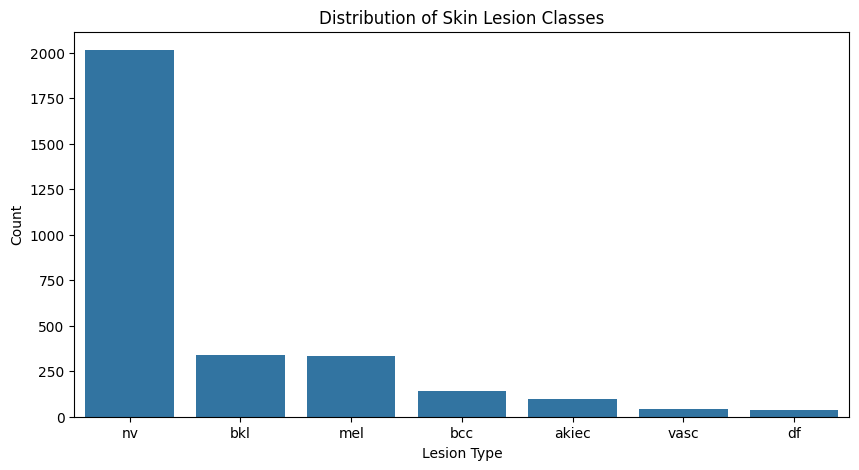

In [53]:
plt.figure(figsize=(10,5))
sns.countplot(x="dx", data=df, order=df["dx"].value_counts().index)
plt.title("Distribution of Skin Lesion Classes")
plt.xlabel("Lesion Type")
plt.ylabel("Count")
plt.show()

## Sample Images

A few sample images from the dataset are displayed to understand the visual characteristics of skin lesions.

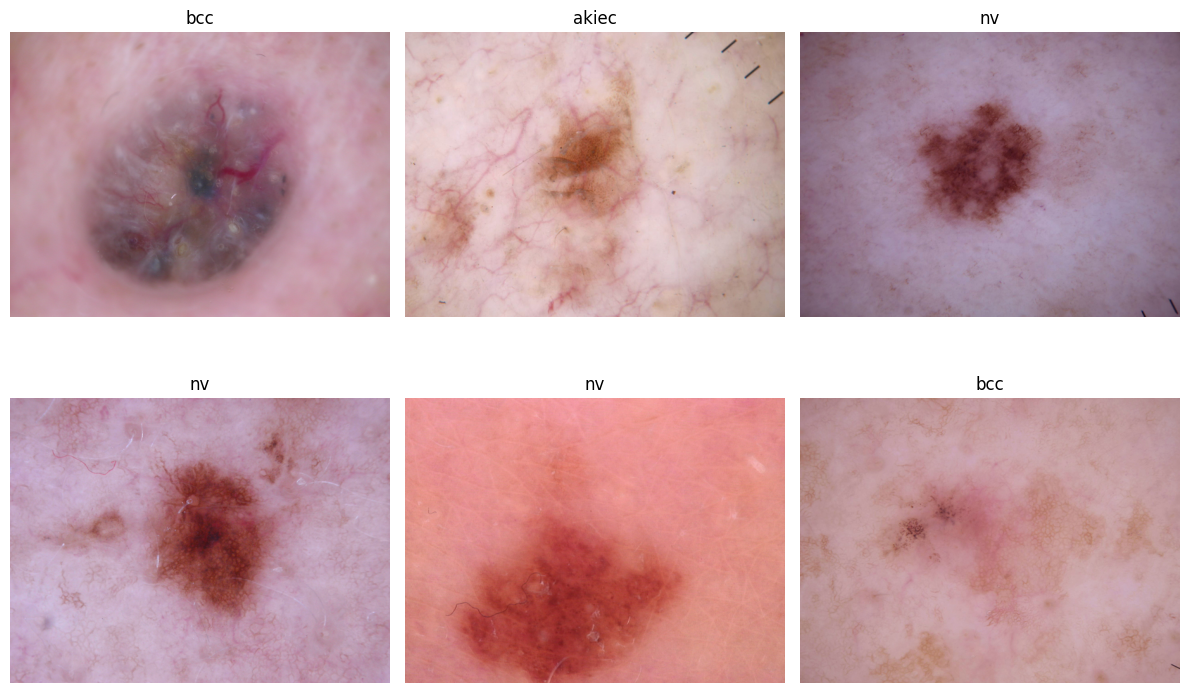

In [54]:
import matplotlib.image as mpimg

plt.figure(figsize=(12,8))

for i in range(6):
    plt.subplot(2, 3, i + 1)
    img = mpimg.imread(df["path"].iloc[i])
    plt.imshow(img)
    plt.title(df["dx"].iloc[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

## Encoding Labels

The lesion types are converted from categorical labels into numerical values so that they can be used for training the model.

In [55]:
label_mapping = {label: idx for idx, label in enumerate(sorted(df["dx"].unique()))}
df["label"] = df["dx"].map(label_mapping)

print(label_mapping)

{'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


## Train-Test Split

The dataset is divided into training and testing sets.  
The training set is used to train the model, and the testing set is used to evaluate its performance.

In [56]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

print("Train size:", len(train_df))
print("Test size:", len(test_df))

Train size: 2400
Test size: 600


## Preparing Labels for Training

Labels are converted to string format for compatibility with the image data generator.

In [57]:
train_df["label_str"] = train_df["label"].astype(str)
test_df["label_str"] = test_df["label"].astype(str)

## Image Preprocessing and Data Augmentation

Image data generators are used to preprocess images and apply transformations such as rotation, zooming, and flipping.

This helps improve model generalization and reduces overfitting.

In [58]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1.0/255)

## Creating Data Generators

Training, validation, and testing generators are created to feed images into the model in batches.

In [59]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="path",
    y_col="label_str",
    target_size=(128, 128),
    batch_size=32,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

val_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="path",
    y_col="label_str",
    target_size=(128, 128),
    batch_size=32,
    class_mode="categorical",
    subset="validation",
    shuffle=True
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="path",
    y_col="label_str",
    target_size=(128, 128),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 1920 validated image filenames belonging to 7 classes.
Found 480 validated image filenames belonging to 7 classes.
Found 600 validated image filenames belonging to 7 classes.


## CNN Model Architecture

A Convolutional Neural Network (CNN) is built to extract features from images and classify them into different categories.

In [60]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation="relu"),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(len(label_mapping), activation="softmax")
])

## Model Compilation

The model is compiled using Adam optimizer and categorical cross-entropy loss.

In [61]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,543 (12.61 MB)

 Trainable params: 3,305,543 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

## Model Training

The model is trained using training data and validated on validation data.

In [62]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [63]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    callbacks=[early_stop]
)

Epoch 1/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 43s 692ms/step - accuracy: 0.6635 - loss: 1.1336 - val_accuracy: 0.6667 - val_loss: 0.9927
Epoch 2/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 34s 565ms/step - accuracy: 0.6698 - loss: 0.9983 - val_accuracy: 0.6667 - val_loss: 0.9366
Epoch 3/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 35s 579ms/step - accuracy: 0.6714 - loss: 0.9745 - val_accuracy: 0.6687 - val_loss: 0.9129
Epoch 4/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 34s 571ms/step - accuracy: 0.6745 - loss: 0.9418 - val_accuracy: 0.6667 - val_loss: 0.9496
Epoch 5/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 36s 597ms/step - accuracy: 0.6708 - loss: 0.9102 - val_accuracy: 0.6667 - val_loss: 0.8713


## Training Accuracy Curve

This graph shows how the model accuracy improves over training epochs.

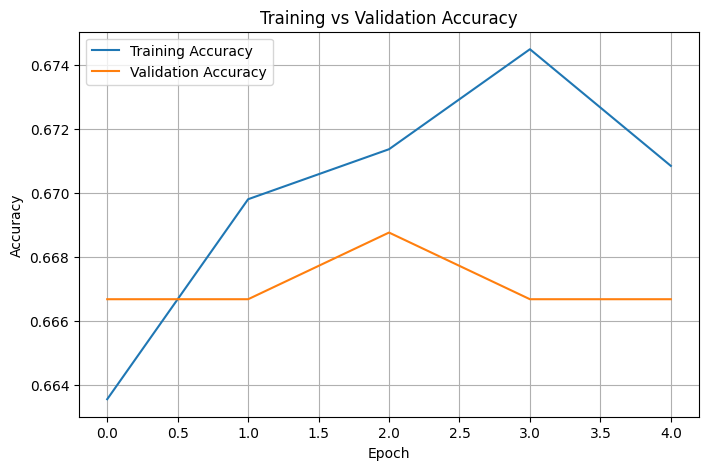

In [64]:
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

## Training Loss Curve

This graph shows how the loss decreases during training.

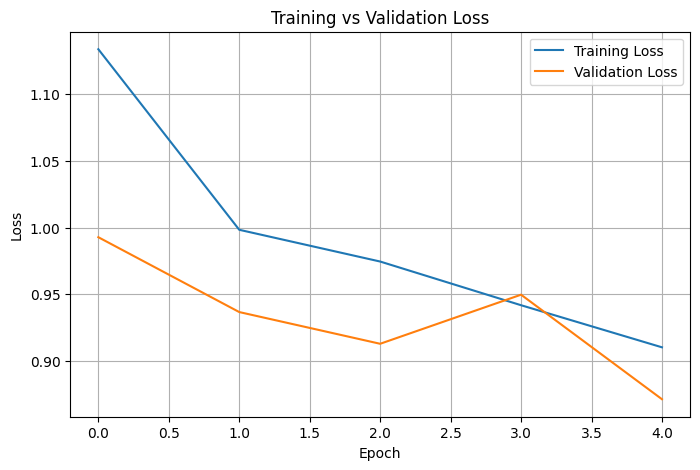

In [65]:
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

## Model Evaluation

The trained model is evaluated on unseen test data to measure performance.

In [66]:
test_loss, test_accuracy = model.evaluate(test_generator)
print("Test Accuracy:", test_accuracy)

19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 293ms/step - accuracy: 0.6733 - loss: 0.8769
Test Accuracy: 0.6733333468437195


## Confusion Matrix

The confusion matrix shows how well the model classifies each category.

19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 222ms/step


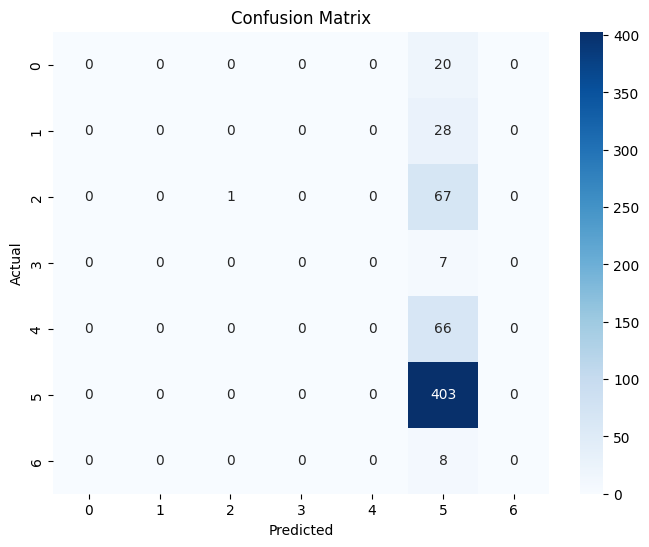

In [67]:
import numpy as np
from sklearn.metrics import confusion_matrix

pred_probs = model.predict(test_generator)
pred_labels = np.argmax(pred_probs, axis=1)

true_labels = test_generator.classes

cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Classification Report

This report provides precision, recall, and F1-score for each class.

In [68]:
from sklearn.metrics import classification_report

print(classification_report(true_labels, pred_labels, zero_division=0))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        20
           1       0.00      0.00      0.00        28
           2       1.00      0.01      0.03        68
           3       0.00      0.00      0.00         7
           4       0.00      0.00      0.00        66
           5       0.67      1.00      0.80       403
           6       0.00      0.00      0.00         8

    accuracy                           0.67       600
   macro avg       0.24      0.14      0.12       600
weighted avg       0.57      0.67      0.54       600



## Class Imbalance Issue

The classification report shows that the model performs well on the majority class but poorly on minority classes.

This is due to class imbalance in the dataset, where some classes have significantly fewer samples than others.

As a result, the model becomes biased toward the dominant class, leading to high overall accuracy but poor performance on minority classes.

## Handling Class Imbalance

To improve model performance, the following techniques can be applied:

- Class weighting during training
- Oversampling minority classes
- Data augmentation for underrepresented classes
- Using advanced architectures such as transfer learning

These techniques can help the model learn balanced representations across all classes.

## Final done